In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Thermal & Phase Property Calculation

In [4]:
T_HCP = np.linspace(300,2500,2200) # 1941
T_IMC = np.linspace(300,2500,2200) # 1603
T_LIQ = np.linspace(1350,2500,1150)
T_FCC = np.linspace(300,1320,1020)

In [5]:
k_LIQ = 100+0.027397*T_LIQ
k_FCC = 339-0.0693*T_FCC
k_HCP = 14.78+4.80727332e-3*T_HCP-1.66755674e-6*T_HCP**2

rho_LIQ = 19325.28-1.44*T_LIQ
rho_FCC = 19657.6-1.2*T_FCC
rho_HCP = 4545.5-0.117609767*T_HCP-6.12812244e-5*T_HCP**2

Sp_LIQ = 158+5.08e7*np.exp(-0.0114*T_LIQ)
Sp_FCC = 132-0.011*T_FCC+2.5e-5*T_FCC**2
Sp_HCP = 545.38+0.1473*T_HCP-5.51e6*T_HCP**-2

# Sp_LIQ = 169+5.08e7*np.exp(-0.0114*T_LIQ)
# Sp_FCC = 127.54-0.011*T_FCC+2.5e-5*T_FCC**2

Coeff_HCP =  1e3*14.594*6.7**2/10.21e-6
Coeff_IMC =  1e3*12.4802*13.66**2/10.21e-6
Coeff_LIQ =  1e3*9.74*2.8**2/10.21e-6
Coeff_FCC =  1e3*12.48*2.67**2/10.21e-6

factor = 8.58e-10
M_HCP = factor*(1.29e-06*np.exp(-6378/(8.31*T_HCP)))
M_IMC = factor*(2.26e-06*np.exp(-2150/(8.31*T_IMC)))
M_LIQ = factor*(3.39e-06*np.exp(-3043/(8.31*T_LIQ)))
M_FCC = factor*(2.03e-06*np.exp(-7501/(8.31*T_FCC)))

Phase_Diffusion_HCP = M_HCP*(Coeff_HCP)
Phase_Diffusion_IMC = M_IMC*(Coeff_IMC)
Phase_Diffusion_LIQ = M_LIQ*(Coeff_LIQ)
Phase_Diffusion_FCC = M_FCC*(Coeff_FCC)

### Thermal

In [6]:
Thermal_Diffusion_FCC  = (339-0.0693*T_FCC)/((19300-1.2*T_FCC)*(132-0.011*T_FCC+2.5e-5*T_FCC**2))
Thermal_Diffusion_LIQ  = (100+0.027397*T_LIQ)/((19300-1.44*T_LIQ)*(158+5.08e7*np.exp(-0.0114*T_LIQ))) 

### Mobility

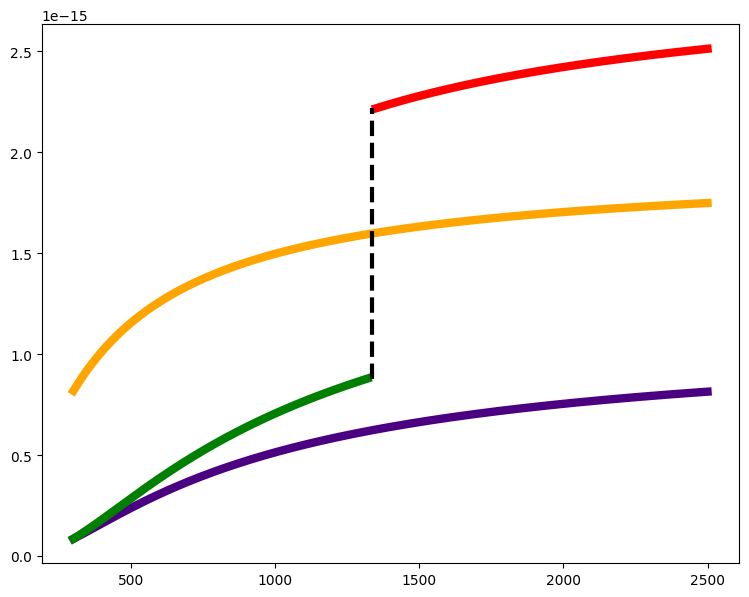

In [5]:
fig, ax1 = plt.subplots(figsize=(9, 7), nrows=1, ncols=1, )
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, )

ax1.plot(T_HCP, M_HCP, linestyle='-', color='indigo', label='$M_{T, HCP}$',linewidth = 6)
ax1.plot(T_IMC, M_IMC, linestyle='-', color='orange', label='$M_{T, IMC}$', linewidth=6)
ax1.plot(T_LIQ, M_LIQ, linestyle='-', color='red', label='$M_{T, LIQ}$',linewidth = 6)
ax1.plot(T_FCC, M_FCC, linestyle='-', color='green', label='$M_{T, FCC}$', linewidth=6)
ax1.vlines(x=1337, ymin=M_FCC[-1], ymax=M_LIQ[0], linestyle='--', color='k', linewidth=3)
plt.show()

# Temperature dependent Material Properties

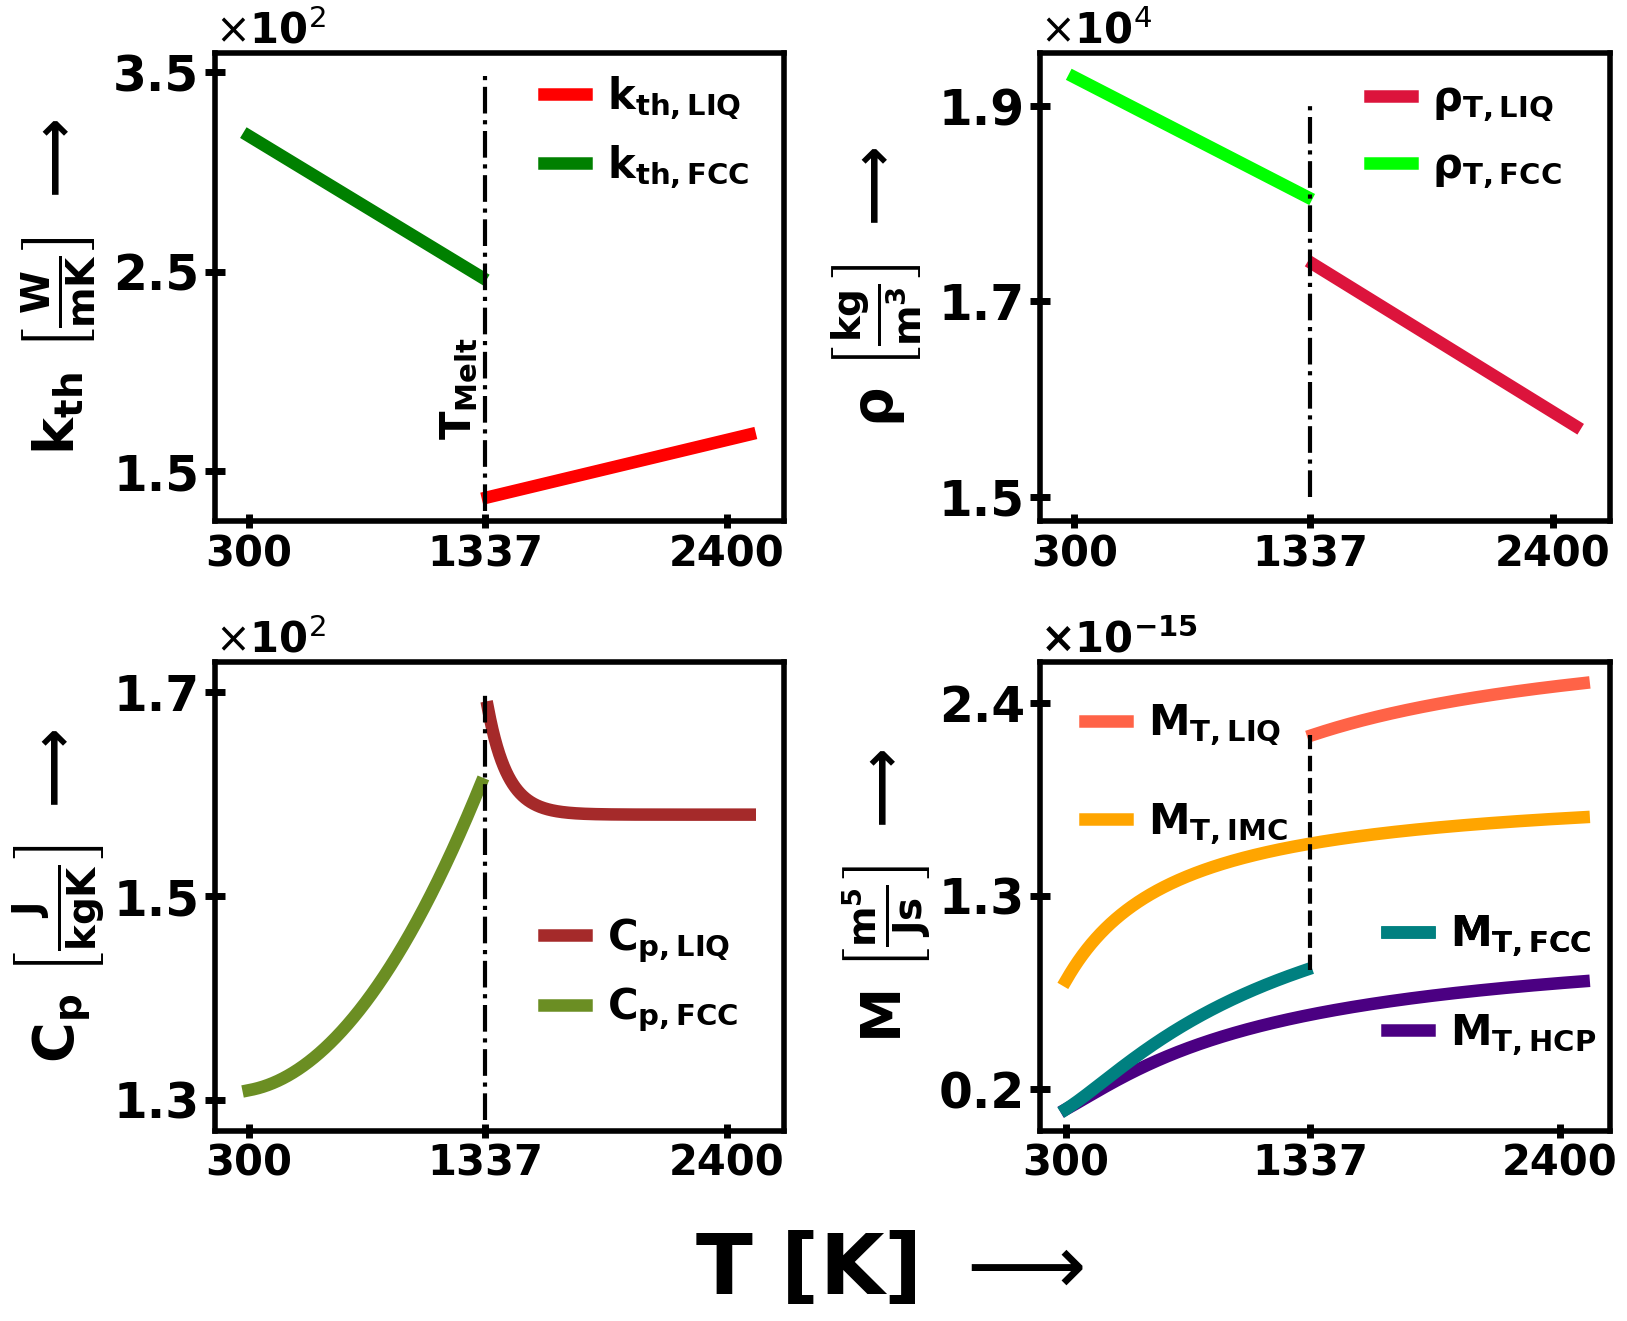

In [8]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(figsize=(18, 14), nrows=2, ncols=2, frameon=False)
ax1.set_facecolor((0, 0, 0, 0))
ax2.set_facecolor((0, 0, 0, 0))
ax3.set_facecolor((0, 0, 0, 0))
ax4.set_facecolor((0, 0, 0, 0))

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.45, hspace=0.3)


ax1.plot(T_LIQ, k_LIQ, '-', color='red', label='$\mathbf{k_{th, LIQ}}$', linewidth= 9)
ax1.plot(T_FCC, k_FCC, '-', color='green', label='$\mathbf{k_{th, FCC}}$', linewidth = 9)
legend1 = ax1.legend(loc=(0.55,0.67), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax1.set_ylabel(r'k$\mathbf{_{th}}$ $\mathbf{\left[\frac{W}{mK}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', labelpad=10, fontsize=40)
ax1.set_yticks([150, 250, 350], labels=[ '1.5', r'2.5', r'3.5'], size=35, color='k', rotation=0,  weight='bold')
ax1.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax1.set_title(r'$\times$10$^2$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax1.set_ylim(125, 360)
ax1.set_xlim(150, 2650)
ax1.vlines(x=1337, ymin=130, ymax=350, linestyle='dashdot', linewidth=3, color='k')
ax1.text(x=1130, y = 170, s=r'T$\mathbf{_{Melt}}$', rotation=90, fontsize=30, weight='bold')

ax2.plot(T_LIQ, rho_LIQ, '-', color='crimson', label=r'$\mathbf{\rho_{T, LIQ}}$', linewidth= 9)
ax2.plot(T_FCC, rho_FCC, '-', color='lime', label=r'$\mathbf{\rho_{T, FCC}}$', linewidth = 9)
legend2 = ax2.legend(loc=(0.55,0.67), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax2.set_ylabel(r'$\mathbf{\rho}$ $\mathbf{\left[\frac{kg}{m^3}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', labelpad=10, fontsize=40)
ax2.set_yticks([15000, 17000, 19000], labels=[ '1.5', '1.7', '1.9'], size=35, color='k', rotation=0,  weight='bold')
ax2.set_title(r'$\times$10$^4$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax2.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax2.set_ylim(14750, 19550)
ax2.set_xlim(150, 2650)
ax2.vlines(x=1337, ymin=15000, ymax=19000, linestyle='dashdot', linewidth=3, color='k')
# ax2.text(x=1130, y = 16000, s=r'T$\mathbf{_{Melt}}$', rotation=90, fontsize=30, weight='bold')

ax3.plot(T_LIQ, Sp_LIQ, '-', color='brown', label=r'$\mathbf{C_{p, LIQ}}$', linewidth= 9)
ax3.plot(T_FCC, Sp_FCC, '-', color='olivedrab', label=r'$\mathbf{C_{p, FCC}}$', linewidth = 9)
legend3 = ax3.legend(loc=(0.55,0.17), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax3.set_ylabel(r'$\mathbf{C_p}$ $\mathbf{\left[\frac{J}{kg K}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', fontsize=40)
ax3.vlines(x=1337, ymin=128, ymax=170, linestyle='dashdot', linewidth=3, color='k')
# ax3.set_xlabel(r'T [K] $\mathbf{\longrightarrow}$', color='k', weight='bold', fontsize=40)
ax3.set_yticks([130, 150, 170], labels=[ '1.3', '1.5', '1.7'], size=35, color='k', rotation=0,  weight='bold')
ax3.set_title(r'$\times$10$^2$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax3.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax3.set_ylim(127, 173)
ax3.set_xlim(150, 2650)


# ax4.plot(T_LIQ, M_LIQ, '-', color='aqua', label=r'$M_{LIQ}$', linewidth= 6)
# ax4.plot(T_FCC, M_FCC, '-', color='brown', label=r'$M_{SOL}$', linewidth = 6)


l_HCP, = ax4.plot(T_HCP, M_HCP, linestyle='-', color='indigo', label='$\mathbf{M_{T, HCP}}$',linewidth = 9)
l_IMC = ax4.plot(T_IMC, M_IMC, linestyle='-', color='orange', label='$\mathbf{M_{T, IMC}}$', linewidth=9)
l_LIQ = ax4.plot(T_LIQ, M_LIQ, linestyle='-', color='tomato', label='$\mathbf{M_{T, LIQ}}$',linewidth = 9)
l_FCC = ax4.plot(T_FCC, M_FCC, linestyle='-', color='teal', label='$\mathbf{M_{T, FCC}}$', linewidth=9)
ax4.vlines(x=1337, ymin=M_FCC[-1], ymax=M_LIQ[0], linestyle='--', color='k', linewidth=3)

lines_4 = ax4.get_lines()

legend_HCP = ax4.legend([lines_4[0]], [lines_4[0].get_label()], loc=(0.58,0.12), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
legend_IMC = ax4.legend([lines_4[1]], [lines_4[1].get_label()], loc=(0.05,0.57), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
legend_LIQ = ax4.legend([lines_4[2]], [lines_4[2].get_label()], loc=(0.05,0.78), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
legend_FCC = ax4.legend([lines_4[3]], [lines_4[3].get_label()], loc=(0.58,0.33), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
ax4.add_artist(legend_HCP)
ax4.add_artist(legend_IMC)
ax4.add_artist(legend_LIQ)
ax4.add_artist(legend_FCC)
ax4.set_ylabel(r'M $\mathbf{\left[\frac{m^5}{J s}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', fontsize=40)
ax4.set_yticks([0.2e-15, 1.3e-15, 2.4e-15], labels=[ '0.2', '1.3', '2.4'], size=35, color='k', rotation=0,  weight='bold')
ax4.set_title(r'$\mathbf{\times}$10$\mathbf{^{-15}}$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax4.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')

ax1.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax1.tick_params(axis='x', direction='inout', which='both', length=10, width=5)
ax2.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax2.tick_params(axis='x', direction='inout', which='both', length=10, width=5)
ax3.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax3.tick_params(axis='x', direction='inout', which='both', length=10, width=5)
ax4.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax4.tick_params(axis='x', direction='inout', which='both', length=10, width=5)

ax1.spines[:].set_linewidth(4)
ax2.spines[:].set_linewidth(4)
ax3.spines[:].set_linewidth(4)
ax4.spines[:].set_linewidth(4)

# fig.text(0.44, 0.48, '_ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _', ha='center', va='center', fontsize=55, rotation=90, color='k')
# fig.text(0.615, 0.5, '__________________', ha='center', va='center', fontsize=45, rotation=90, color='k')
fig.text(0.5, 0.01, r'T [K] $\longrightarrow$', ha='center', va='center', fontsize=60, weight='bold')

# plt.savefig('figures/Mat_props.jpg', bbox_inches='tight')
# plt.savefig('figures/Mat_props.png', bbox_inches='tight', dpi=800)

# plt.savefig('for_manuscript/T_u/F8/jpg/mat_prop.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/mat_prop.png', bbox_inches='tight', dpi=800)

# plt.tight_layout()
plt.show()

## Individual Figures

### Thermal Conductivity

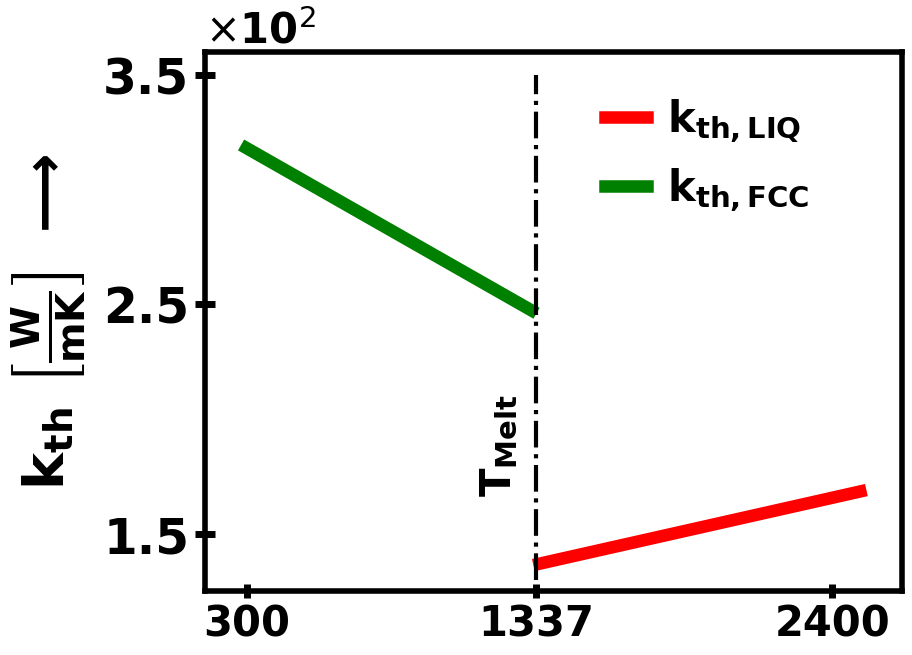

In [9]:
fig, ax1 = plt.subplots(figsize=(9, 7), nrows=1, ncols=1, frameon=False)
ax1.set_facecolor((0, 0, 0, 0))

ax1.plot(T_LIQ, k_LIQ, '-', color='red', label='$\mathbf{k_{th, LIQ}}$', linewidth= 9)
ax1.plot(T_FCC, k_FCC, '-', color='green', label='$\mathbf{k_{th, FCC}}$', linewidth = 9)
legend1 = ax1.legend(loc=(0.55,0.67), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax1.set_ylabel(r'k$\mathbf{_{th}}$ $\mathbf{\left[\frac{W}{mK}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', labelpad=10, fontsize=40)
ax1.set_yticks([150, 250, 350], labels=[ '1.5', r'2.5', r'3.5'], size=35, color='k', rotation=0,  weight='bold')
ax1.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax1.set_title(r'$\times$10$^2$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax1.set_ylim(125, 360)
ax1.set_xlim(150, 2650)
ax1.vlines(x=1337, ymin=130, ymax=350, linestyle='dashdot', linewidth=3, color='k')
ax1.text(x=1130, y = 170, s=r'T$\mathbf{_{Melt}}$', rotation=90, fontsize=30, weight='bold')
ax1.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax1.tick_params(axis='x', direction='inout', which='both', length=10, width=5)
ax1.spines[:].set_linewidth(4)
# plt.tight_layout()
# plt.savefig('for_manuscript/T_u/F8/jpg/thermal_condt.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/thermal_condt.png', bbox_inches='tight', dpi=800)
plt.show()

### Density

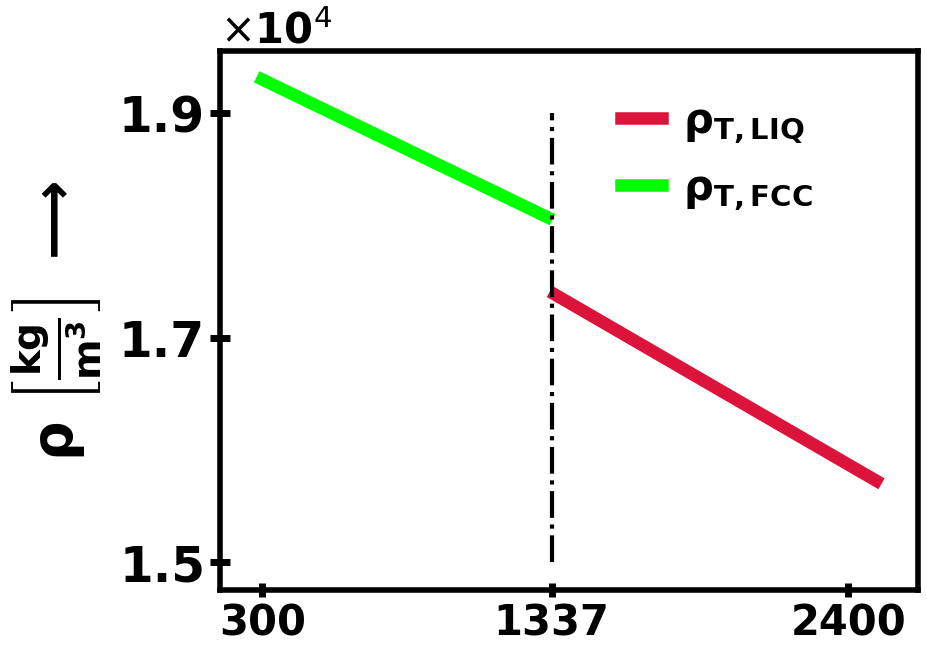

In [10]:
fig, ax2 = plt.subplots(figsize=(9, 7), nrows=1, ncols=1, frameon=False)
ax2.set_facecolor((0, 0, 0, 0))

ax2.plot(T_LIQ, rho_LIQ, '-', color='crimson', label=r'$\mathbf{\rho_{T, LIQ}}$', linewidth= 9)
ax2.plot(T_FCC, rho_FCC, '-', color='lime', label=r'$\mathbf{\rho_{T, FCC}}$', linewidth = 9)
legend2 = ax2.legend(loc=(0.55,0.67), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax2.set_ylabel(r'$\mathbf{\rho}$ $\mathbf{\left[\frac{kg}{m^3}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', labelpad=10, fontsize=40)
ax2.set_yticks([15000, 17000, 19000], labels=[ '1.5', '1.7', '1.9'], size=35, color='k', rotation=0,  weight='bold')
ax2.set_title(r'$\times$10$^4$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax2.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax2.set_ylim(14750, 19550)
ax2.set_xlim(150, 2650)
ax2.vlines(x=1337, ymin=15000, ymax=19000, linestyle='dashdot', linewidth=3, color='k')
# ax2.text(x=1130, y = 16000, s=r'T$\mathbf{_{Melt}}$', rotation=90, fontsize=30, weight='bold')
ax2.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax2.tick_params(axis='x', direction='inout', which='both', length=10, width=5)

ax2.spines[:].set_linewidth(4)

# plt.tight_layout
# plt.savefig('for_manuscript/T_u/F8/jpg/density.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/density.png', bbox_inches='tight', dpi=800)
plt.show()

### Specific Heat

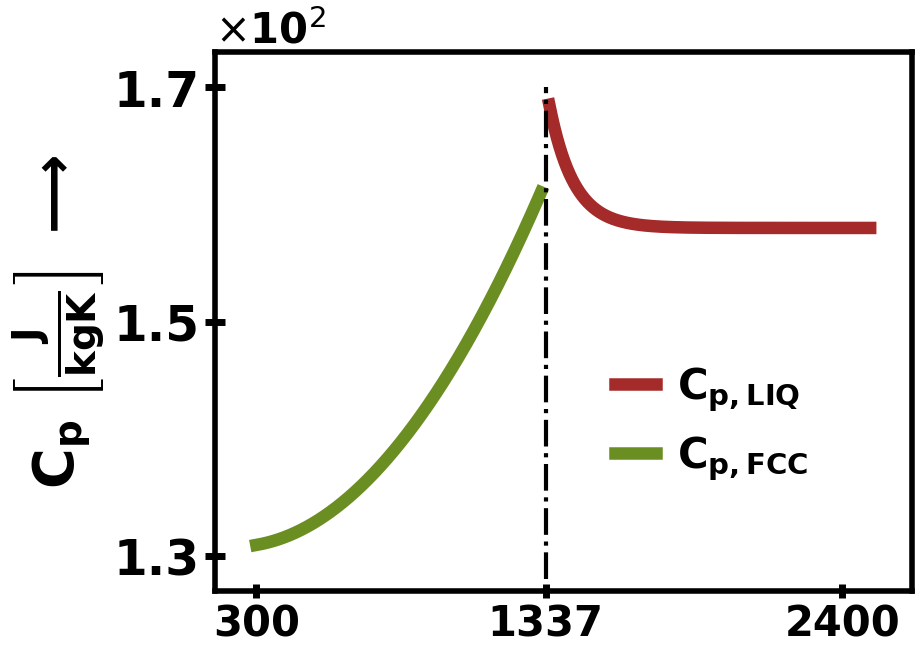

In [11]:
fig, ax3 = plt.subplots(figsize=(9, 7), nrows=1, ncols=1, frameon=False)
ax3.set_facecolor((0, 0, 0, 0))

ax3.plot(T_LIQ, Sp_LIQ, '-', color='brown', label=r'$\mathbf{C_{p, LIQ}}$', linewidth= 9)
ax3.plot(T_FCC, Sp_FCC, '-', color='olivedrab', label=r'$\mathbf{C_{p, FCC}}$', linewidth = 9)
legend3 = ax3.legend(loc=(0.55,0.17), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax3.set_ylabel(r'$\mathbf{C_p}$ $\mathbf{\left[\frac{J}{kg K}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', fontsize=40)
ax3.vlines(x=1337, ymin=128, ymax=170, linestyle='dashdot', linewidth=3, color='k')
# ax3.set_xlabel(r'T [K] $\mathbf{\longrightarrow}$', color='k', weight='bold', fontsize=40)
ax3.set_yticks([130, 150, 170], labels=[ '1.3', '1.5', '1.7'], size=35, color='k', rotation=0,  weight='bold')
ax3.set_title(r'$\times$10$^2$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax3.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax3.set_ylim(127, 173)
ax3.set_xlim(150, 2650)
ax3.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax3.tick_params(axis='x', direction='inout', which='both', length=10, width=5)
ax3.spines[:].set_linewidth(4)
# plt.tight_layout()
# plt.savefig('for_manuscript/T_u/F8/jpg/specific_heat.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/specific_heat.png', bbox_inches='tight', dpi=800)
plt.show()


### Mobility

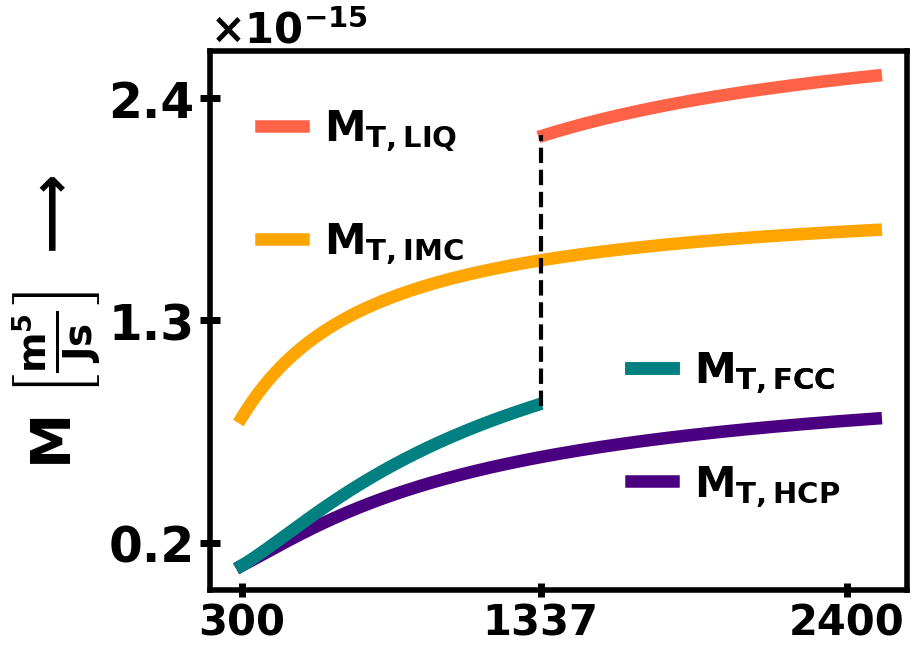

In [12]:
fig, ax4 = plt.subplots(figsize=(9, 7), nrows=1, ncols=1, frameon=False)
ax4.set_facecolor((0, 0, 0, 0))

l_HCP, = ax4.plot(T_HCP, M_HCP, linestyle='-', color='indigo', label='$\mathbf{M_{T, HCP}}$',linewidth = 9)
l_IMC = ax4.plot(T_IMC, M_IMC, linestyle='-', color='orange', label='$\mathbf{M_{T, IMC}}$', linewidth=9)
l_LIQ = ax4.plot(T_LIQ, M_LIQ, linestyle='-', color='tomato', label='$\mathbf{M_{T, LIQ}}$',linewidth = 9)
l_FCC = ax4.plot(T_FCC, M_FCC, linestyle='-', color='teal', label='$\mathbf{M_{T, FCC}}$', linewidth=9)
ax4.vlines(x=1337, ymin=M_FCC[-1], ymax=M_LIQ[0], linestyle='--', color='k', linewidth=3)

lines_4 = ax4.get_lines()

legend_HCP = ax4.legend([lines_4[0]], [lines_4[0].get_label()], loc=(0.58,0.12), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
legend_IMC = ax4.legend([lines_4[1]], [lines_4[1].get_label()], loc=(0.05,0.57), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
legend_LIQ = ax4.legend([lines_4[2]], [lines_4[2].get_label()], loc=(0.05,0.78), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
legend_FCC = ax4.legend([lines_4[3]], [lines_4[3].get_label()], loc=(0.58,0.33), prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0, frameon=False)
ax4.add_artist(legend_HCP)
ax4.add_artist(legend_IMC)
ax4.add_artist(legend_LIQ)
ax4.add_artist(legend_FCC)
ax4.set_ylabel(r'M $\mathbf{\left[\frac{m^5}{J s}\right]}$ $\mathbf{\longrightarrow}$', color='k', weight='bold', fontsize=40)
ax4.set_yticks([0.2e-15, 1.3e-15, 2.4e-15], labels=[ '0.2', '1.3', '2.4'], size=35, color='k', rotation=0,  weight='bold')
ax4.set_title(r'$\mathbf{\times}$10$\mathbf{^{-15}}$', pad=0, loc='left', color='black', fontsize=30, weight='bold')
ax4.set_xticks([300, 1337, 2400], labels=['300', '1337', '2400'], size=30, color='k', weight='bold')
ax4.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax4.tick_params(axis='x', direction='inout', which='both', length=10, width=5)

ax4.spines[:].set_linewidth(4)
# plt.tight_layout()
# plt.savefig('for_manuscript/T_u/F8/jpg/mobility.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/mobility.png', bbox_inches='tight', dpi=800)
plt.show()

# Free Energy

In [2]:
def Gibbs_HCP(c_temp):
    c, T = c_temp
    F, A, a, c0, B, b, T0, C = 1000, 14.594, 6.7, 0.68, 4.1, 0.0015, 1.65, -6.95
    return F*(A*(a*c-c0)**2 + B*(b*T-T0)**2 + C)

def Gibbs_IMC(c_temp):
    c, T = c_temp
    F, A, a, c0, B, b, T0, C = 1000, 12.4802, 13.66, 3.5655, 1.9, 0.0034, 2.921, -12.6
    return F*(A*(a*c-c0)**2 + B*(b*T-T0)**2 + C)
  
 
def Gibbs_LIQ(c_temp):
    c, T = c_temp
    F, A, a, c0, B, b, T0, C, D = 11.599, 43, 5.14, 2.71, 112, 0.0033, 6.4, -0.75, -21
    return F*(A*(a*c - c0)**4 + B*(b*T - T0)**2 + C*c*T + D)
    # F, A, a, c0, B, b, T0, C = 1000, 9.74, 2.8, 1.64, 3.9, 0.002, 4.5, -12.82
    # return F*(A*(a*c-c0)**2 + B*(b*T-T0)**2 + C)

def Gibbs_FCC(c_temp):
    c, T = c_temp
    F, A, a, c0, B, b, T0, C, D = 19.858, 9.66, 5.2745, 3.307, 118.0749, 0.00352, 2.0883, -0.75, -5.8
    # F, A, a, c0, B, b, T0, C, D = 14.8, 38.0435, 5.6888, 3.6607, 8.19, 0.00361, 3.4439, -0.75, -5.8
    return F*(A*(a*c - c0)**6 + B*(b*T - T0)**2 + C*c*T + D)
    # F, A, a, c0, B, b, T0, C = 1000, 10.34, 2.67, 1.743, 3.76, 0.0027, 2.15, -8.5
    # return F*(A*(a*c-c0)**2 + B*(b*T-T0)**2 + C)



In [2]:
def Gibbs_HCP(c_temp):
    c, T = c_temp
    F, A, c0, B, T0, C, D = 1000, 655.12466, 0.10149253731343284,  9.225e-06, 1100.0, 0, -6.95
    return F*(A*(c-c0)**2 + B*(T-T0)**2 + C*c*T + D)

def Gibbs_IMC(c_temp):
    c, T = c_temp
    F, A, c0, B, T0, C, D = 1000, 2328.75040712, 0.26101756954612004, 2.1964e-05, 859.1176470588235, 0, -12.6
    return F*(A*(c-c0)**2 + B*(T-T0)**2 + C*c*T + D)

def Gibbs_LIQ(c_temp):
    c, T = c_temp
    F, A, c0, B, T0, C, D = 11.599, 30013.79635887999, 0.5272373540856031, 0.00121968, 1939.3939393939395, -0.75, -21
    return F*(A*(c - c0)**4 + B*(T - T0)**2 + C*c*T + D)

def Gibbs_FCC(c_temp):
    c, T = c_temp
    F, A, c0, B, T0, C, D = 19.858, 208000.75262426224, 0.6269788605555029, 0.0014629952409600001, 593.2670454545454, -0.75, -5.8
    return F*(A*(c - c0)**6 + B*(T - T0)**2 + C*c*T + D)


In [3]:
# Perform the optimization to find the minimum
HCP_min = minimize(Gibbs_HCP, x0=[0.08, 1200], method= 'Powell', bounds=[(0, 1), (0, 2500)])
IMC_min = minimize(Gibbs_IMC, x0=[0.25, 1000], method= 'Powell', bounds=[(0, 1), (0, 2500)])
LIQ_min = minimize(Gibbs_LIQ, x0=[0.7, 1800], method= 'Powell', bounds=[(0, 1), (0, 2500)])
FCC_min = minimize(Gibbs_FCC, x0=[0.6, 800], method= 'Powell', bounds=[(0, 1), (0, 2500)])

# Extract the minimum x and y values
c1_, T1_ = HCP_min.x
c2_, T2_ = IMC_min.x
c3_, T3_ = LIQ_min.x
c4_, T4_ = FCC_min.x

# Get the minimum value of the function
F_min_HCP = HCP_min.fun
F_min_IMC = IMC_min.fun
F_min_LIQ = LIQ_min.fun
F_min_FCC = FCC_min.fun

# Print the results
print(f'F1 min = {round(F_min_HCP,1)} |  |  (c1, temp) = {round(c1_,4), round(T1_,1)}')
print(f'F2 min = {round(F_min_IMC,1)} |  |  (c2, temp) = {round(c2_,4), round(T2_,1)}')
print(f'F3 min = {round(F_min_LIQ,1)} |  |  (c3, temp) = {round(c3_,4), round(T3_,1)}')
print(f'F4 min = {round(F_min_FCC,1)}  |  |  (c4, temp) = {round(c4_,4), round(T4_,1)}')

F1 min = -6950.0 |  |  (c1, temp) = (0.1015, 1100.0)
F2 min = -12600.0 |  |  (c2, temp) = (0.261, 859.1)
F3 min = -12820.3 |  |  (c3, temp) = (0.7658, 2174.9)
F4 min = -8500.8  |  |  (c4, temp) = (0.8445, 809.7)


In [4]:
c = np.linspace(0, 1, 1000)
T = np.linspace(0, 3200, 1000)

F_HCP = Gibbs_HCP(np.meshgrid(c, T))
F_IMC = Gibbs_IMC(np.meshgrid(c, T))
F_LIQ = Gibbs_LIQ(np.meshgrid(c, T))
F_FCC = Gibbs_FCC(np.meshgrid(c, T))

# Filter values to keep only negative ones
G_HCP_neg = np.where(F_HCP < 0, F_HCP, np.nan)
G_IMC_neg = np.where(F_IMC < 0, F_IMC, np.nan)
G_LIQ_neg = np.where(F_LIQ < 0, F_LIQ, np.nan)
G_FCC_neg = np.where(F_FCC < 0, F_FCC, np.nan)


/tmp/ipykernel_96150/2703067818.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


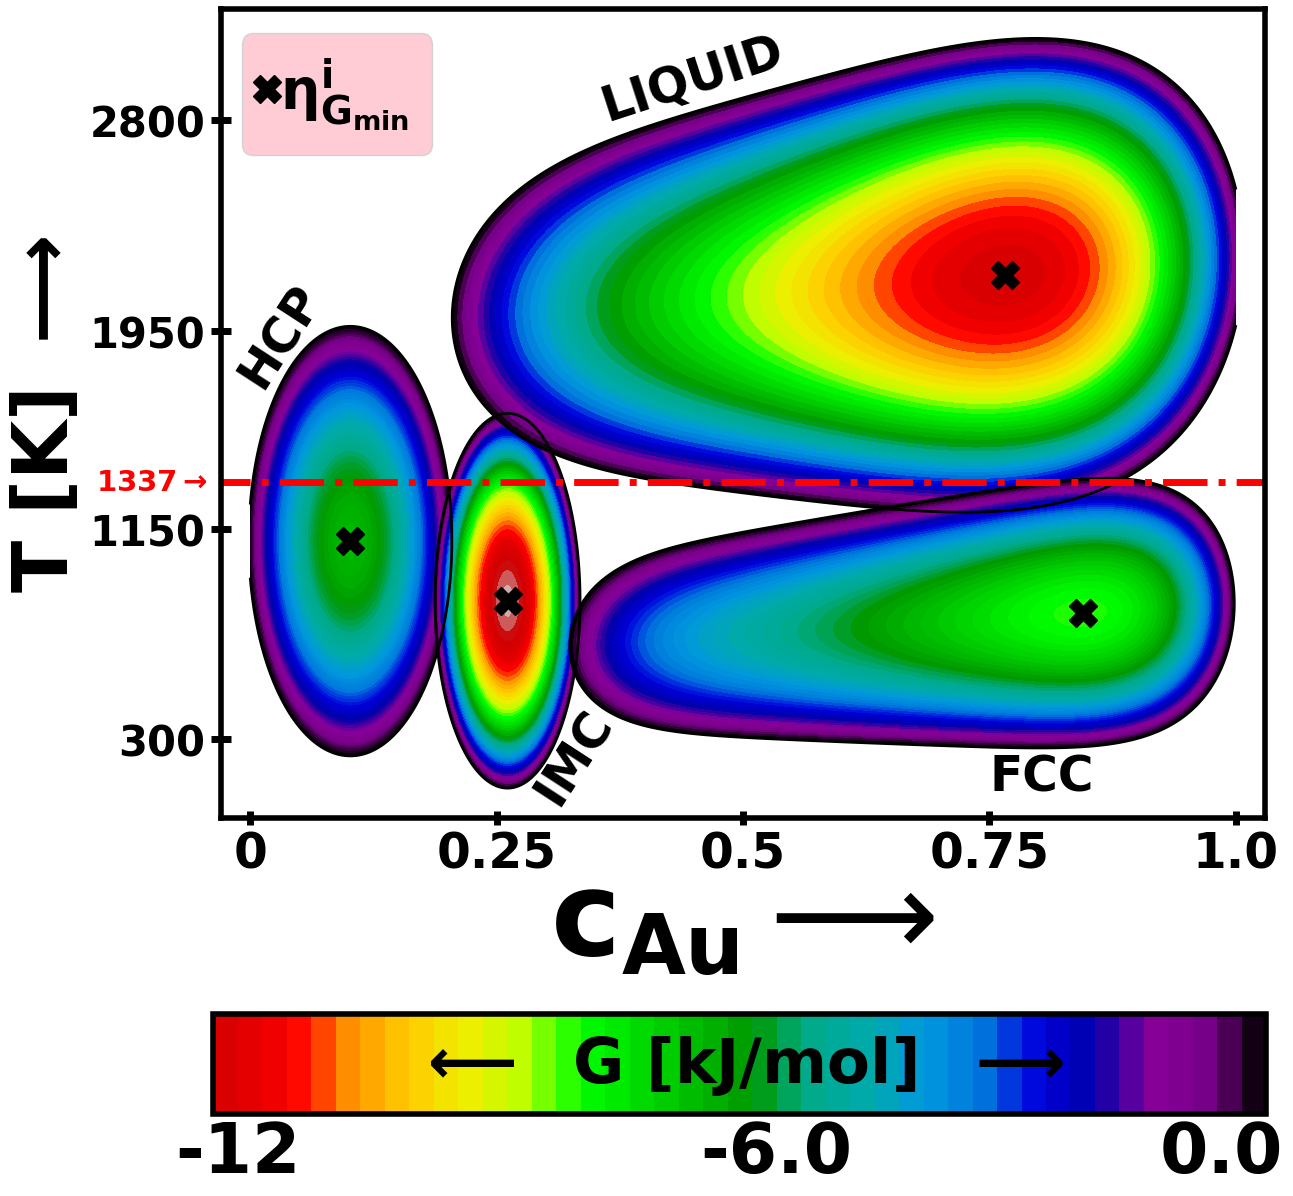

In [7]:
fig, ax1 = plt.subplots(1,1, figsize=(13,10), frameon=False)
ax1.set_facecolor((0, 0, 0, 0))

hcp_ = ax1.contourf(c, T, G_HCP_neg, cmap='nipy_spectral_r', vmin= -14000, vmax=0, levels=50)
imc_ = ax1.contourf(c, T, G_IMC_neg, cmap='nipy_spectral_r',  levels=50)
liq_ = ax1.contourf(c, T, G_LIQ_neg, cmap='nipy_spectral_r', vmin= -14000, vmax=0, levels=50)
fcc_ = ax1.contourf(c, T, G_FCC_neg, cmap='nipy_spectral_r', vmin= -14000, vmax=0, levels=50) # nipy_spectral_r

ax1.contour(c, T, F_HCP, levels=[0], colors='black', linewidths=2)
ax1.contour(c, T, F_IMC, levels=[0], colors='black', linewidths=2)
ax1.contour(c, T, F_LIQ, levels=[0], colors='black', linewidths=2)
ax1.contour(c, T, F_FCC, levels=[0], colors='black', linewidths=2)

ax1.plot(round(c1_,4), round(T1_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k', label=r'$\mathbf{\eta^i_{G_{min}}}$') # label=r'$\mathbf{\phi_i^{G_{min}}}$'
ax1.plot(round(c2_,4), round(T2_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k')
ax1.plot(round(c3_,4), round(T3_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k')
ax1.plot(round(c4_,4), round(T4_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k')
ax1.legend(loc=(0.02, 0.82), ncol=1,  columnspacing=1.0, prop={'weight':'bold', 'size':'40',}, 
           handletextpad=0.2, handlelength=0.1,   frameon=True).get_frame().set_facecolor('pink')


ax1.hlines(y=1337, xmin=-0.12, xmax=1.1, colors='red', linestyle='dashdot', linewidth=5)


ax1.set_xlabel(r'c$\mathbf{_{Au}} \longrightarrow$', weight='bold', labelpad=-10, fontsize=85)
ax1.set_ylabel('T [K] $\mathbf{\longrightarrow}$',  weight='bold', fontsize=55)
# ax1.tick_params(axis='both', labelcolor='black', labelsize=65, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

ax1.set_yticks([300, 1150, 1950, 2800], labels=['300', '1150', '1950', '2800'], size=30, color='k', weight='bold')
ax1.set_xticks([0, 0.25,  0.5, 0.75, 1.0], labels=['0', '0.25', '0.5', '0.75', '1.0'], size=35, color='k', weight='bold')
ax1.set_ylim(-20,3250)
ax1.set_xlim(-0.03,1.03)

ax1.text(x=-0.02, y = 1730, s=r'HCP', color='k', weight='bold', fontsize=35, rotation=57)
ax1.text(x=0.28, y = 45, s=r'IMC', color='k', weight='bold', fontsize=35, rotation=57)
ax1.text(x=0.35, y = 2800, s=r'LIQUID', color='k', weight='bold', fontsize=35, rotation = 18)
ax1.text(x=0.75, y = 90, s=r'FCC', color='k', weight='bold', fontsize=35, )

ax1.text(-0.1, 1337, r'1337$\mathbf{\rightarrow}$', ha='center', va='center', color='red', fontsize=21, weight='bold')


ax2 = fig.add_axes([0.168, -0.12, 0.81, 0.1])
ax2.tick_params(axis='both', labelcolor='black', labelsize=1, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
cbar = fig.colorbar(liq_, cax=ax2, orientation='horizontal')
cbar.ax.tick_params(labelsize=50, direction='inout', length=0, width=5)

cbar.set_ticks([-12600, -6000, -550],labels=['-12', '-6.0', '0.0',], weight='bold') 
cbar.set_label(r'$\mathbf{\longleftarrow}$  G [$\mathbf{kJ/mol}$]  $\mathbf{\longrightarrow}$', color='k', labelpad=-110, fontsize=45, rotation=0, weight='bold')

ax1.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax1.tick_params(axis='x', direction='inout', which='both', length=10, width=5)

ax2.spines[:].set_linewidth(4)
ax1.spines[:].set_linewidth(4)

plt.tight_layout()

# plt.savefig('for_manuscript/T_u/F8/jpg/gibbs_free_energy.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/gibbs_free_energy.png', bbox_inches='tight', dpi=800)

plt.show()

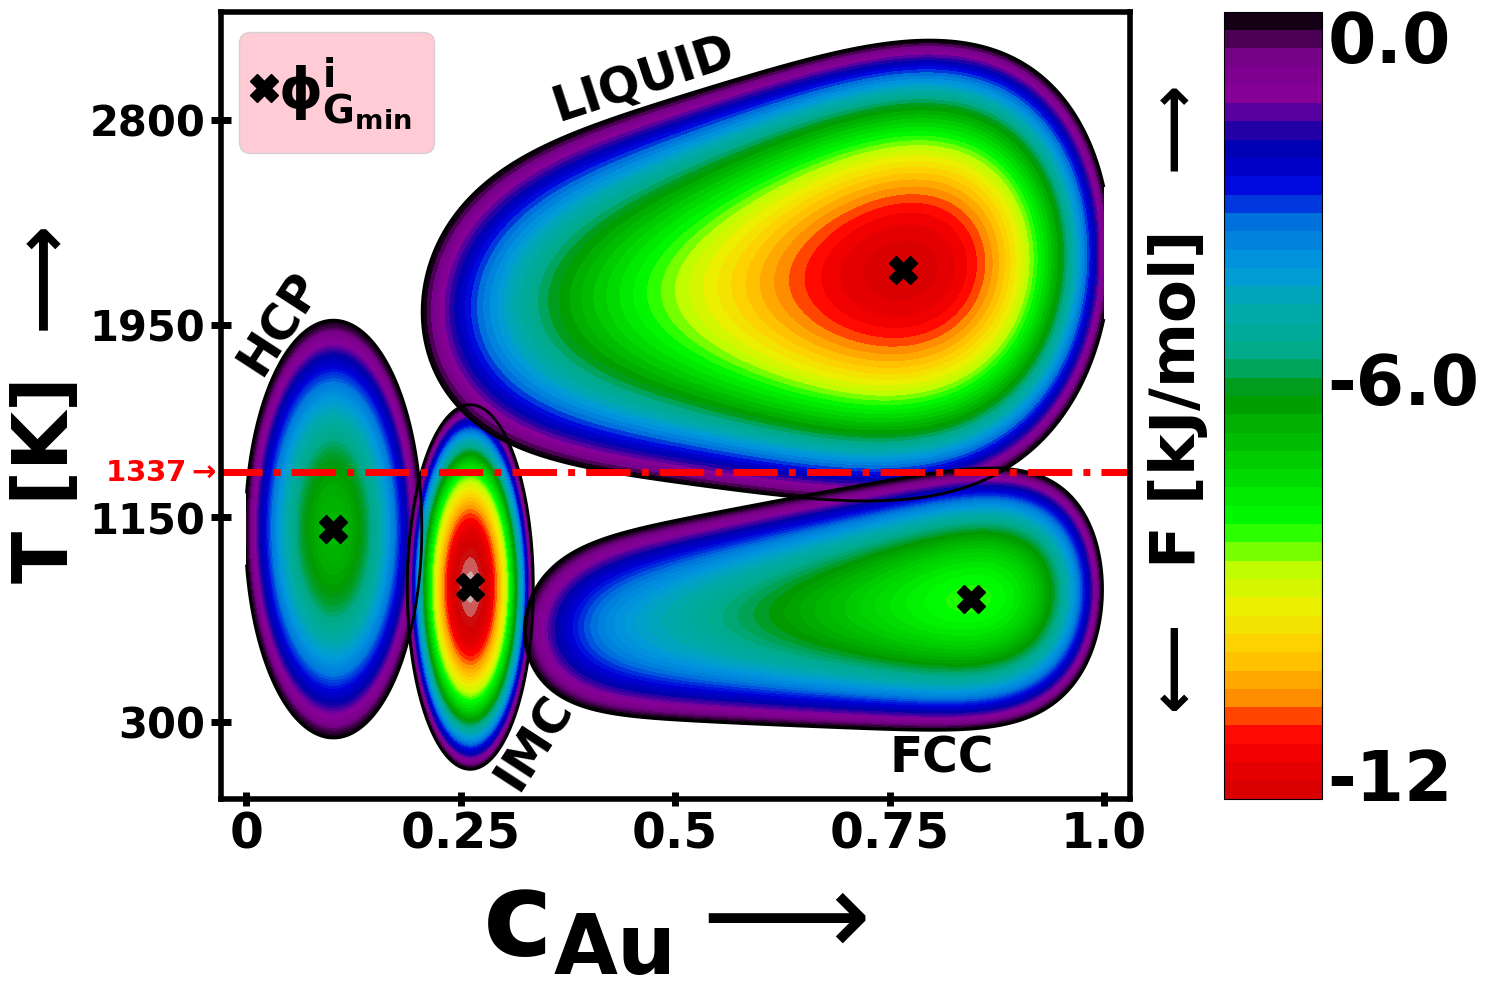

In [205]:
fig, ax1 = plt.subplots(1,1, figsize=(15,10), frameon=False)
ax1.set_facecolor((0, 0, 0, 0))

hcp_ = ax1.contourf(c, T, G_HCP_neg, cmap='nipy_spectral_r', vmin= -14000, vmax=0, levels=50)
imc_ = ax1.contourf(c, T, G_IMC_neg, cmap='nipy_spectral_r',  levels=50)
liq_ = ax1.contourf(c, T, G_LIQ_neg, cmap='nipy_spectral_r', vmin= -14000, vmax=0, levels=50)
fcc_ = ax1.contourf(c, T, G_FCC_neg, cmap='nipy_spectral_r', vmin= -14000, vmax=0, levels=50) # nipy_spectral_r

cbar = fig.colorbar(liq_, label='Gibbs  [J/mol]',aspect=8, pad=0.08)
cbar.ax.tick_params(labelsize=50, direction='inout', length=0, width=5)
cbar.set_ticks([-12500, -6000, -400],labels=['-12', '-6.0', '0.0',], weight='bold') 
cbar.set_label(r'$\mathbf{\longleftarrow}$  F [$\mathbf{kJ/mol}$]  $\mathbf{\longrightarrow}$', color='black', labelpad=-240, fontsize=45, rotation=90, weight='bold')
# cbar.tick_params(axis='y', direction='inout', which='both', length=15, width=5)


ax1.contour(c, T, F_HCP, levels=[0], colors='black', linewidths=2)
ax1.contour(c, T, F_IMC, levels=[0], colors='black', linewidths=2)
ax1.contour(c, T, F_LIQ, levels=[0], colors='black', linewidths=2)
ax1.contour(c, T, F_FCC, levels=[0], colors='black', linewidths=2)


ax1.plot(round(c1_,4), round(T1_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k', label=r'$\mathbf{\phi^i_{G_{min}}}$') # label=r'$\mathbf{\phi_i^{G_{min}}}$'
ax1.plot(round(c2_,4), round(T2_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k')
ax1.plot(round(c3_,4), round(T3_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k')
ax1.plot(round(c4_,4), round(T4_,1), marker='X', color='k', markersize=20, markeredgecolor='k', markerfacecolor='k')
ax1.legend(loc=(0.02, 0.82), ncol=1,  columnspacing=1.0, prop={'weight':'bold', 'size':'40',}, 
           handletextpad=0.2, handlelength=0.1,   frameon=True).get_frame().set_facecolor('pink')


ax1.hlines(y=1337, xmin=-0.12, xmax=1.1, colors='red', linestyle='dashdot', linewidth=5)


ax1.set_xlabel(r'c$\mathbf{_{Au}} \longrightarrow$', weight='bold', fontsize=85)
ax1.set_ylabel('T [K] $\mathbf{\longrightarrow}$',  weight='bold', fontsize=55)
# ax1.tick_params(axis='both', labelcolor='black', labelsize=65, bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

ax1.set_yticks([300, 1150, 1950, 2800], labels=['300', '1150', '1950', '2800'], size=30, color='k', weight='bold')
ax1.set_xticks([0, 0.25,  0.5, 0.75, 1.0], labels=['0', '0.25', '0.5', '0.75', '1.0'], size=35, color='k', weight='bold')
ax1.set_ylim(-20,3250)
ax1.set_xlim(-0.03,1.03)

# ax1.text(x=-0.02, y = 1730, s=r'HCP', color='k', weight='bold', fontsize=30, rotation=57)
# ax1.text(x=0.28, y = 50, s=r'IMC', color='k', weight='bold', fontsize=30, rotation=57)
# ax1.text(x=0.80, y = 2760, s=r'LIQUID', color='k', weight='bold', fontsize=30, rotation = -30)
# ax1.text(x=0.75, y = 120, s=r'FCC', color='k', weight='bold', fontsize=30, )

ax1.text(x=-0.02, y = 1750, s=r'HCP', color='k', weight='bold', fontsize=35, rotation=57)
ax1.text(x=0.28, y = 25, s=r'IMC', color='k', weight='bold', fontsize=35, rotation=57)
ax1.text(x=0.35, y = 2800, s=r'LIQUID', color='k', weight='bold', fontsize=35, rotation = 18)
ax1.text(x=0.75, y = 90, s=r'FCC', color='k', weight='bold', fontsize=35, )

ax1.text(-0.1, 1337, r'1337$\mathbf{\rightarrow}$', ha='center', va='center', color='red', fontsize=21, weight='bold')

ax1.tick_params(axis='y', direction='inout', which='both', length=15, width=5)
ax1.tick_params(axis='x', direction='inout', which='both', length=10, width=5)
ax1.spines[:].set_linewidth(4)

plt.tight_layout()

# plt.savefig('for_manuscript/T_u/F8/jpg/gibbs_free_energy_v.jpg', bbox_inches='tight')
# plt.savefig('for_manuscript/T_u/F8/gibbs_free_energy_v.png', bbox_inches='tight', dpi=800)

plt.show()

In [5]:
Gibbs_IMC((0.261, 800)), Gibbs_FCC((0.653, 800))

(-12523.23738114048, -8499.621310566)

In [4]:
factor = 8.58e-10
M_IMC = factor*(2.26e-06*np.exp(-2150/(8.31*800)))
M_FCC = factor*(2.03e-06*np.exp(-7501/(8.31*800)))
M_IMC, M_FCC

(1.40327402868757e-15, 5.635920231847041e-16)

# Test

(0.0, 0.01)

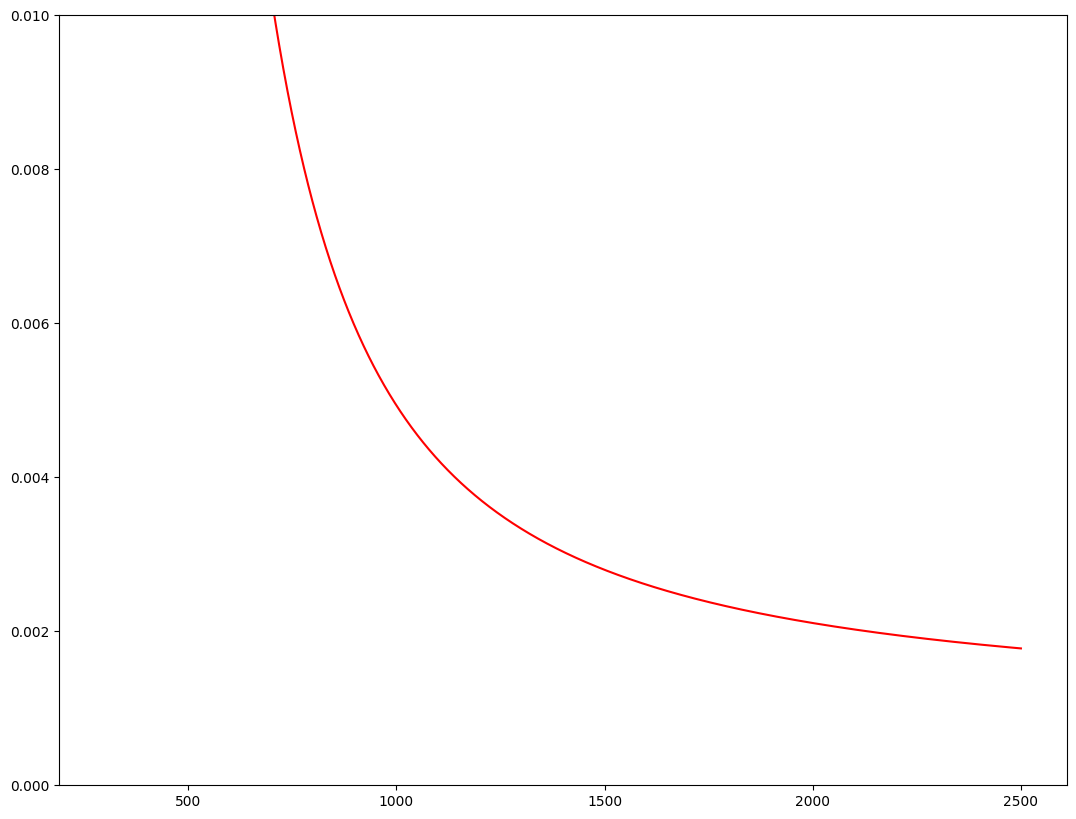

In [9]:
mu0 = 9e-4
mu1 = 8.3e-3
Ea = 4725
Eb = 0.3342
R = 8.31
T = np.linspace(300,2500,2200)

mu_LIQ = mu0*np.exp((Ea/Eb)/(R*T))

fig, ax1 = plt.subplots(1,1, figsize=(13,10), frameon=True)
ax1.plot(T, mu_LIQ, color='red')
ax1.set_ylim(0,0.01)

## Ratio

In [ ]:
ratio_SOL = Thermal_Diffusion_SOL / Species_Diffusion_SOL
ratio_LIQ = Thermal_Diffusion_LIQ / Species_Diffusion_LIQ

## Plotting

In [ ]:
fig, (ax14, ax3) = plt.subplots(figsize=(24, 9), nrows=1, ncols=2, )
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.5, )


ax14.plot(T_LIQ, Species_Diffusion_LIQ*1e4, '-', color='indigo', label='$D_{\eta, LIQ}$', linewidth= 6)
ax14.plot(T_SOL, Species_Diffusion_SOL*1e4, '--', color='indigo', label='$D_{\eta, FCC}$', linewidth = 6)
legend1 = ax14.legend(loc=(0.01,0.15), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=2.0,   frameon=False).get_frame().set_facecolor('none')
ax14.set_ylabel('D$_{\eta}$ [$cm^2$/s]  $\longrightarrow$', color='indigo', weight='bold', fontsize=25)
ax14.set_xlabel(r'Temperature [K] $\longrightarrow$', color='k', weight='bold', fontsize=30)
ax14.tick_params(axis='both', labelsize=25)
ax14.yaxis.set_tick_params(labelcolor='tab:blue', labelsize=25)  
ax14.set_yticks([1e-7, 5e-7, 9e-7], labels=[ '1e-7', r'5e-7', r'9e-7'], size=30, rotation=00,  weight='bold')
ax14.set_ylim(1.3e-12, 1.0e-6)


###########################

ax2 = ax14.twinx()

ax2.plot(T_LIQ, Thermal_Diffusion_LIQ*1e4, '-', color='red', label='$D_{T, LIQ}$',linewidth = 6)
ax2.plot(T_SOL, Thermal_Diffusion_SOL*1e4, '--', color='red', label='$D_{T, FCC}$', linewidth=6)
legend2 = ax2.legend(loc=(0.65,0.65), ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=2.0,   frameon=False).get_frame().set_facecolor('none')
ax2.set_ylabel('D$_{T}$ [$cm^2$/s]  $\longrightarrow$', color='red', weight='bold', labelpad=-15, fontsize=25)
ax2.tick_params(axis='y',labelcolor='tab:red', labelsize=30)
ax2.tick_params(axis='x',labelcolor='k', labelsize=30)
ax2.set_yticks([0.01, 0.60, 1.30], labels=[ '0.01', r'0.6', r'1.3'], size=30, rotation=00,  weight='bold')
ax2.set_xlabel(r'Temperature [K] $\longrightarrow$', color='k', weight='bold', fontsize=30)
ax2.set_ylim(-0.3, 1.38)

ax2.vlines(x=1325, ymin=-0.3, ymax=1.37, linestyle='dashdot', linewidth=3, color='k')
ax2.text(x=1350, y = 0.75, s='Melting Point', rotation=90, fontsize=20, weight='bold')
ax2.text(x=1230, y = -0.01, s='1337 K', rotation=90, fontsize=20, weight='bold')

 
ax2.annotate('$\longleftarrow$     SOLID     $\longrightarrow$', xy=(0.24, 0.97),  rotation=00,
             xycoords='axes fraction', textcoords='axes fraction', fontsize = 20, weight = 'bold',
             color='blue', ha='center', va='center')

ax2.annotate('$\longleftarrow$      LIQUID      $\longrightarrow$', xy=(0.72, 0.97),  rotation=00,
             xycoords='axes fraction', textcoords='axes fraction', fontsize = 20, weight = 'bold',
             color='crimson', ha='center', va='center')
###########################


ax3.plot(T_SOL, ratio_SOL, '--',  color='green', label=r'$D_{\frac{T}{\eta}, FCC}$', linewidth = 6)
ax3.set_yticks([0.1e8, 0.6e8, 1.2e8], labels=[ '0.1e8', r'0.6e8', r'1.2e8'], size=30, rotation=0,  weight='bold')
ax3.yaxis.set_tick_params(labelcolor='green', labelsize=25)  
ax3.set_ylim(0.05e8, 1.25e8)
ax3.set_xlim(200, 2600)
ax3.set_xlabel(r'Temperature [K] $\longrightarrow$', color='k', weight='bold', fontsize=30)
ax3.tick_params(axis='both', labelsize=25)
ax3.set_ylabel(r'(D$_{T}$/D$_{\eta}$)$_{FCC}$ $\longrightarrow$', color='green', weight='bold', fontsize=30)

legend3 = ax3.legend(loc=(0.1,0.3), ncol=1, columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.9,  frameon=False).get_frame().set_facecolor('none')

###########################

ax4 = ax3.twinx()

ax4.plot(T_LIQ, ratio_LIQ, linestyle= '-', color='magenta', label=r'$D_{\frac{T}{\eta}, LIQ}$',linewidth = 6)
# ax4.plot(T_SOL, ratio_SOL, '-',  color='green', label=r'$D_{\frac{T}{\eta}, SOL}$', linewidth = 6)
ax4.set_yticks([1.4e6, 1.60e6, 1.80e6], labels=[ '1.4e6', r'1.6e6', r'1.8e6'], size=30, rotation=0,  weight='bold')
ax4.yaxis.set_tick_params(labelcolor='magenta', labelsize=25)  
ax4.set_ylim(1.37e6, 1.82e6)
ax4.vlines(x=1337, ymin=0, ymax=2.1e6, linestyle='dashdot', linewidth=3, color='k')
ax4.text(x=1360, y = 1.65e6, s='Melting Point', rotation=90, fontsize=20, weight='bold')
ax4.text(x=1230, y = 1.45e6, s='1337 K', rotation=90, fontsize=20, weight='bold')
ax4.set_ylabel(r'(D$_{T}$/D$_{\eta}$)$_{LIQ}$ $\longrightarrow$', color='magenta', weight='bold', fontsize=30)

legend4 = ax4.legend(loc=(0.68,0.3), ncol=1, columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.9,  frameon=False).get_frame().set_facecolor('none')

ax4.annotate('$\longleftarrow$     SOLID     $\longrightarrow$', xy=(0.24, 0.97),  rotation=00, xycoords='axes fraction', 
             textcoords='axes fraction', fontsize = 20, weight = 'bold', color='blue', ha='center', va='center')

ax4.annotate('$\longleftarrow$      LIQUID      $\longrightarrow$', xy=(0.72, 0.97),  rotation=00, xycoords='axes fraction', 
             textcoords='axes fraction', fontsize = 20, weight = 'bold', color='crimson', ha='center', va='center')
###########################

fig.text(0.5, 0.5, '- - - - - - - - - - - - - - - - - - ', ha='center', va='center', fontsize=40, rotation=90, color='k')

for label in ax14.get_xticklabels(): label.set_fontweight('bold')
for label in ax14.get_yticklabels(): label.set_fontweight('bold')
for label in ax2.get_xticklabels(): label.set_fontweight('bold')
for label in ax2.get_yticklabels(): label.set_fontweight('bold')
for label in ax3.get_xticklabels(): label.set_fontweight('bold')
for label in ax3.get_yticklabels(): label.set_fontweight('bold')
for label in ax4.get_xticklabels(): label.set_fontweight('bold')
for label in ax4.get_yticklabels(): label.set_fontweight('bold')

fig.text(0.06,0.9,'(a)', ha='center', va='center', fontsize=40, rotation=0, color='k', weight = 'bold')
fig.text(0.52,0.9,'(b)', ha='center', va='center', fontsize=40, rotation=0, color='k', weight = 'bold')

# plt.savefig('figures/Diffusivity_Ratio.png', bbox_inches='tight', dpi=800)

plt.show()

In [ ]:


# fig, ((ax14, ax2),(ax3, ax4)) = plt.subplots(figsize=(16, 14), nrows=2, ncols=2, )
fig, (ax14, ax2, ax3) = plt.subplots(figsize=(22, 6), nrows=1, ncols=3, )
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.3)


ax14.plot(T_LIQ, k_LIQ, '-', color='red', label='$k_{th, LIQ}$', linewidth= 6)
ax14.plot(T_SOL, k_SOL, '-', color='green', label='$k_{th, SOL}$', linewidth = 6)
legend1 = ax14.legend(loc=1, ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax14.set_ylabel('Thermal Conduct. [W/mK]', color='k', weight='bold', fontsize=20)
ax14.set_xlabel(r'Temperature [K]', color='k', weight='bold', fontsize=25)
ax14.tick_params(axis='both', labelsize=25)
ax14.set_yticks([150, 250, 350], labels=[ '150', r'250', r'350'], size=30, rotation=00,  weight='bold')
ax14.yaxis.set_tick_params(labelcolor='k', labelsize=25)  
ax14.set_ylim(130, 360)
ax14.vlines(x=1337, ymin=140, ymax=360, linestyle='dashdot', linewidth=3, color='k')
ax14.text(x=1200, y = 170, s='1337 K', rotation=90, fontsize=20, weight='bold')


ax2.plot(T_LIQ, rho_LIQ, '-', color='magenta', label=r'$\rho_{T, LIQ}$', linewidth= 6)
ax2.plot(T_SOL, rho_SOL, '-', color='lime', label=r'$\rho_{T, SOL}$', linewidth = 6)
legend2 = ax2.legend(loc=1, ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax2.set_ylabel(r'Density [kg/m$^3$]', color='k', weight='bold', fontsize=25)
ax2.set_xlabel(r'Temperature [K]', color='k', weight='bold', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)
ax2.vlines(x=1337, ymin=15000, ymax=19000, linestyle='dashdot', linewidth=3, color='k')
ax2.text(x=1200, y = 15500, s='1337 K', rotation=90, fontsize=20, weight='bold')

ax2.get_yaxis().get_offset_text().set_position((-0.01, 0))
ax2.ticklabel_format(axis='y', style='scientific', scilimits=(0,0), useMathText=True)
ax2.yaxis.offsetText.set(size=25, weight='bold', color='red')
ax2.yaxis.set_major_locator(plt.MaxNLocator(5))


ax3.plot(T_LIQ, Sp_LIQ, '-', color='blue', label=r'$C_{p, LIQ}$', linewidth= 6)
ax3.plot(T_SOL, Sp_SOL, '-', color='darkorange', label=r'$C_{p, SOL}$', linewidth = 6)
legend3 = ax3.legend(loc=4, ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
ax3.set_ylabel(r'Specific Heat [J/kg K]', color='k', weight='bold', fontsize=25)
ax3.set_xlabel(r'Temperature [K]', color='k', weight='bold', fontsize=25)
ax3.tick_params(axis='both', labelsize=23)
ax3.vlines(x=1337, ymin=130, ymax=170, linestyle='dashdot', linewidth=3, color='k')
ax3.text(x=1200, y = 135, s='1337 K', rotation=90, fontsize=20, weight='bold')
ax3.yaxis.set_major_locator(plt.MaxNLocator(4))
ax3.xaxis.set_major_locator(plt.MaxNLocator(4))


# ax4.plot(T_LIQ, M_LIQ, '-', color='aqua', label=r'$M_{LIQ}$', linewidth= 6)
# ax4.plot(T_SOL, M_SOL, '-', color='brown', label=r'$M_{SOL}$', linewidth = 6)
# legend4 = ax4.legend(loc=4, ncol=1,  columnspacing=0.5, prop={'weight':'bold', 'size':'30',}, handletextpad=0.5, handlelength=1.0,   frameon=False).get_frame().set_facecolor('none')
# ax4.set_ylabel(r'Mobility [m$^5$/J s]', color='k', weight='bold', fontsize=25)
# ax4.set_xlabel(r'Temperature [K]', color='k', weight='bold', fontsize=25)
# ax4.tick_params(axis='both', labelsize=23)
# ax4.vlines(x=1337, ymin=0.1e-6, ymax=3e-6, linestyle='dashdot', linewidth=3, color='k')
# ax4.text(x=1200, y = 1.5e-6, s='1337 K', rotation=90, fontsize=20, weight='bold')
# ax4.get_yaxis().get_offset_text().set_position((-0.01, 0))
# ax4.ticklabel_format(axis='y', style='scientific', scilimits=(0,0), useMathText=True)
# ax4.yaxis.offsetText.set(size=25, weight='bold', color='red')
# ax4.yaxis.set_major_locator(plt.MaxNLocator(3))
# ax4.xaxis.set_major_locator(plt.MaxNLocator(4))
# ax4.set_ylim(0, 3.2e-6)

for label in ax14.get_xticklabels(): label.set_fontweight('bold')
for label in ax14.get_yticklabels(): label.set_fontweight('bold')
for label in ax2.get_xticklabels(): label.set_fontweight('bold')
for label in ax2.get_yticklabels(): label.set_fontweight('bold')
for label in ax3.get_xticklabels(): label.set_fontweight('bold')
for label in ax3.get_yticklabels(): label.set_fontweight('bold')
# for label in ax4.get_xticklabels(): label.set_fontweight('bold')
# for label in ax4.get_yticklabels(): label.set_fontweight('bold')

fig.text(0.335, 0.5, '__________________', ha='center', va='center', fontsize=45, rotation=90, color='k')
fig.text(0.615, 0.5, '__________________', ha='center', va='center', fontsize=45, rotation=90, color='k')


# plt.savefig('figures/Temperature_Dependent_Properties.png', bbox_inches='tight', dpi=800)

plt.show()